# Physical validation notebook for the one-loop fRG kernel

This notebook is for **diagnosis**, not for rewriting the kernel.

It tests whether the current `frg_kernel.py` behaves in a physically sensible way at the kernel level.

## What this notebook checks

1. **Algebraic sanity**
   - zero interaction gives zero kernel
   - kernel scales as \(U^2\)

2. **Spin / symmetry sanity**
   - no fake spin splitting for an SU(2)-symmetric input
   - simple block-level symmetry proxies, especially in the pp block

3. **Minimal physics trend**
   - compare pp / ph / ph' norms and leading eigenvalues
   - scan temperature and look for smooth trends

4. **Debug guidance**
   - if a test fails, the notebook points to the most likely source:
     index mapping, propagator, or loop construction

## Important limitation

A **full fermionic antisymmetry test of \(\delta\Gamma\)** really belongs to the next step, where the three channels are reassembled into a single four-leg object \(d\Gamma/dT\).

This notebook therefore focuses on the strongest tests you can already do **at the channel-kernel level**.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path
import sys

sys.path.append('/mnt/data')

import frg_kernel as fk

np.set_printoptions(precision=5, suppress=True)


## 1. Standalone synthetic testbed

The default testbed below is intentionally simple:

- spinful
- patch-based
- SU(2)-symmetric onsite Hubbard vertex
- identical patch sets for up/down

This is **not** intended to reproduce full kagome physics by itself.  
Its job is to catch artificial symmetry breaking and bad scaling in the kernel implementation.

You can later replace `patchsets` and `gamma_fn` by your real Module 1 objects in the optional section near the end.


In [4]:
@dataclass
class Patch:
    k_cart: np.ndarray
    energy: float

@dataclass
class PatchSet:
    patches: list
    b1: np.ndarray
    b2: np.ndarray

    @property
    def Npatch(self):
        return len(self.patches)


def make_ring_patchsets(Npatch=12, radius=1.0, mu=0.2):
    """Symmetric ring of patches with identical up/down sectors.

    Dispersion choice is deliberately simple.  It is only a testbed for
    channel-level diagnostics, not a realistic kagome band structure.
    """
    angles = np.linspace(0.0, 2.0*np.pi, Npatch, endpoint=False)
    patches = []
    for th in angles:
        k = np.array([radius*np.cos(th), radius*np.sin(th)], dtype=float)
        energy = np.cos(th) - mu
        patches.append(Patch(k_cart=k, energy=float(energy)))
    ps = PatchSet(
        patches=patches,
        b1=np.array([20.0, 0.0]),
        b2=np.array([0.0, 20.0]),
    )
    return {"up": ps, "dn": ps}


def make_hubbard_gamma(U):
    """Momentum-independent antisymmetrized onsite Hubbard test vertex.

    Γ(1,2,3,4) = U [δ_{s1,s3}δ_{s2,s4} - δ_{s1,s4}δ_{s2,s3}]
    """
    def gamma(p1, s1, p2, s2, p3, s3, p4, s4):
        return U * (
            float((s1 == s3) and (s2 == s4))
            - float((s1 == s4) and (s2 == s3))
        )
    return gamma


patchsets = make_ring_patchsets(Npatch=12, radius=1.0, mu=0.2)
Q_pp = np.array([0.0, 0.0])      # Cooper test
Q_ph = np.array([2.0, 0.0])      # simple 'nesting-like' transfer for the toy model

cfg = fk.FlowConfig(temperature=0.2, nfreq=128)
gamma_U1 = make_hubbard_gamma(U=1.0)


## 2. Small utilities

In [6]:
def kernel_norm(K):
    return float(np.linalg.norm(K))

def leading_eval_real(K):
    vals = np.linalg.eigvalsh(np.real_if_close(K))
    return float(vals[-1])

def summarize_kernel(name, K):
    return {
        "name": name,
        "norm": kernel_norm(K),
        "max_abs": float(np.max(np.abs(K))),
        "leading_eval_real": leading_eval_real(K),
        "transpose_error": float(np.max(np.abs(K - K.T))),
    }

def print_summary(summary):
    print(f"{summary['name']}: norm={summary['norm']:.6g}, max|K|={summary['max_abs']:.6g}, "
          f"leading_eval(real)={summary['leading_eval_real']:.6g}, "
          f"transpose_error={summary['transpose_error']:.3e}")


## 3. Algebraic sanity checks

In [8]:
# 3a. Zero-interaction test
gamma_zero = make_hubbard_gamma(U=0.0)

Kpp0  = fk.compute_pp_kernel(gamma_zero, patchsets, Q_pp, incoming_spins=("up", "dn"), config=cfg).matrix
Kph0  = fk.compute_ph_kernel(gamma_zero, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfg).matrix
Kphc0 = fk.compute_phc_kernel(gamma_zero, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfg).matrix

print("Zero-interaction max norms:")
print("pp :", kernel_norm(Kpp0))
print("ph :", kernel_norm(Kph0))
print("ph':", kernel_norm(Kphc0))


Zero-interaction max norms:
pp : 0.0
ph : 0.0
ph': 0.0


In [9]:
# 3b. U^2 scaling test
U_values = [0.2, 0.4, 0.8]
rows = []

for U in U_values:
    gU = make_hubbard_gamma(U=U)
    Kpp  = fk.compute_pp_kernel(gU, patchsets, Q_pp, incoming_spins=("up", "dn"), config=cfg).matrix
    Kph  = fk.compute_ph_kernel(gU, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfg).matrix
    Kphc = fk.compute_phc_kernel(gU, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfg).matrix
    rows.append((U, kernel_norm(Kpp), kernel_norm(Kph), kernel_norm(Kphc)))

print("Expected: norms should scale approximately like U^2")
for row in rows:
    print(row)


Expected: norms should scale approximately like U^2
(0.2, 2.0799521233326543, 1.3219000759131023, 1.3219000759131023)
(0.4, 8.319808493330617, 5.287600303652409, 5.287600303652409)
(0.8, 33.27923397332247, 21.150401214609637, 21.150401214609637)


## 4. Spin / symmetry sanity checks

In [11]:
# 4a. No fake spin splitting in an SU(2)-symmetric setup
Kph_uu = fk.compute_ph_kernel(gamma_U1, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfg).matrix
Kph_dd = fk.compute_ph_kernel(gamma_U1, patchsets, Q_ph, incoming_spins=("dn", "dn"), config=cfg).matrix

Kpp_ud = fk.compute_pp_kernel(gamma_U1, patchsets, Q_pp, incoming_spins=("up", "dn"), config=cfg).matrix
Kpp_du = fk.compute_pp_kernel(gamma_U1, patchsets, Q_pp, incoming_spins=("dn", "up"), config=cfg).matrix

print("SU(2) proxy checks")
print("max|Kph_uu - Kph_dd| =", np.max(np.abs(Kph_uu - Kph_dd)))
print("max|Kpp_ud - Kpp_du| =", np.max(np.abs(Kpp_ud - Kpp_du)))


SU(2) proxy checks
max|Kph_uu - Kph_dd| = 0.0
max|Kpp_ud - Kpp_du| = 0.0


In [12]:
# 4b. Simple block-level symmetry proxies
Kpp = fk.compute_pp_kernel(gamma_U1, patchsets, Q_pp, incoming_spins=("up", "dn"), config=cfg).matrix
Kph = fk.compute_ph_kernel(gamma_U1, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfg).matrix
Kphc = fk.compute_phc_kernel(gamma_U1, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfg).matrix

for summary in [
    summarize_kernel("pp (up,dn)", Kpp),
    summarize_kernel("ph (up,up)", Kph),
    summarize_kernel("ph' (up,up)", Kphc),
]:
    print_summary(summary)


pp (up,dn): norm=51.9988, max|K|=4.33323, leading_eval(real)=51.9988, transpose_error=0.000e+00
ph (up,up): norm=33.0475, max|K|=2.75396, leading_eval(real)=33.0475, transpose_error=0.000e+00
ph' (up,up): norm=33.0475, max|K|=2.75396, leading_eval(real)=2.17259e-05, transpose_error=0.000e+00


Interpretation:

- `transpose_error` should be tiny when symmetry says the block should be symmetric.
- `Kph_uu` and `Kph_dd` should match for this SU(2)-symmetric test input.
- If these fail badly, suspect:
  - spin-block wiring
  - shifted patch mapping
  - wrong external-leg convention


## 5. Minimal physics trend test

In [15]:
temperatures = [0.5, 0.3, 0.2, 0.1, 0.05]
scan = []

for T in temperatures:
    cfgT = fk.FlowConfig(temperature=T, nfreq=256)

    KppT = fk.compute_pp_kernel(gamma_U1, patchsets, Q_pp, incoming_spins=("up", "dn"), config=cfgT).matrix
    KphT = fk.compute_ph_kernel(gamma_U1, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfgT).matrix
    KphcT = fk.compute_phc_kernel(gamma_U1, patchsets, Q_ph, incoming_spins=("up", "up"), config=cfgT).matrix

    scan.append({
        "T": T,
        "pp_norm": kernel_norm(KppT),
        "ph_norm": kernel_norm(KphT),
        "phc_norm": kernel_norm(KphcT),
        "pp_lead": leading_eval_real(KppT),
        "ph_lead": leading_eval_real(KphT),
        "phc_lead": leading_eval_real(KphcT),
    })

scan


[{'T': 0.5,
  'pp_norm': 68.26349275148475,
  'ph_norm': 122.47890933091469,
  'phc_norm': 122.47890933091469,
  'pp_lead': 1.063105627554967e-14,
  'ph_lead': 1.7483483894188535e-07,
  'phc_lead': 122.47890933091463},
 {'T': 0.3,
  'pp_norm': 4.513637784405295,
  'ph_norm': 82.13341761381021,
  'phc_norm': 82.13341761381021,
  'pp_lead': 4.513637784405294,
  'ph_lead': 8.094172698131218e-07,
  'phc_lead': 82.13341761381022},
 {'T': 0.2,
  'pp_norm': 50.582406179024645,
  'ph_norm': 31.6310465827352,
  'phc_norm': 31.6310465827352,
  'pp_lead': 50.58240617902463,
  'ph_lead': 31.631046582734772,
  'phc_lead': 2.731761838132772e-06},
 {'T': 0.1,
  'pp_norm': 165.35037023637526,
  'ph_norm': 69.6762112841759,
  'phc_norm': 69.6762112841759,
  'pp_lead': 8.625136258732714e-15,
  'ph_lead': 69.67621128416395,
  'phc_lead': 2.1853163578223164e-05},
 {'T': 0.05,
  'pp_norm': 245.2877269128873,
  'ph_norm': 16.71092232447221,
  'phc_norm': 16.71092232447221,
  'pp_lead': 4.426730458394393e-15

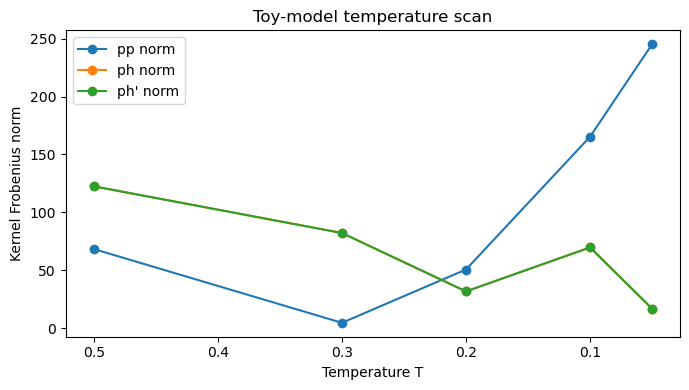

In [16]:
Ts = np.array([row["T"] for row in scan], dtype=float)
pp_norms = np.array([row["pp_norm"] for row in scan], dtype=float)
ph_norms = np.array([row["ph_norm"] for row in scan], dtype=float)
phc_norms = np.array([row["phc_norm"] for row in scan], dtype=float)

plt.figure(figsize=(7,4))
plt.plot(Ts, pp_norms, marker="o", label="pp norm")
plt.plot(Ts, ph_norms, marker="o", label="ph norm")
plt.plot(Ts, phc_norms, marker="o", label="ph' norm")
plt.gca().invert_xaxis()
plt.xlabel("Temperature T")
plt.ylabel("Kernel Frobenius norm")
plt.title("Toy-model temperature scan")
plt.legend()
plt.tight_layout()
plt.show()


How to read this section:

- You are **not** looking for universal dominance in the toy model.
- You are checking for:
  - smooth dependence on temperature
  - no erratic sign flips
  - no obvious numerical instability
  - sensible separation of channels when the setup favors one transfer more than another

If trends are wildly unstable under changes of `nfreq`, the problem is more likely Matsubara handling than channel indexing.


## 6. Heatmaps of the three kernels

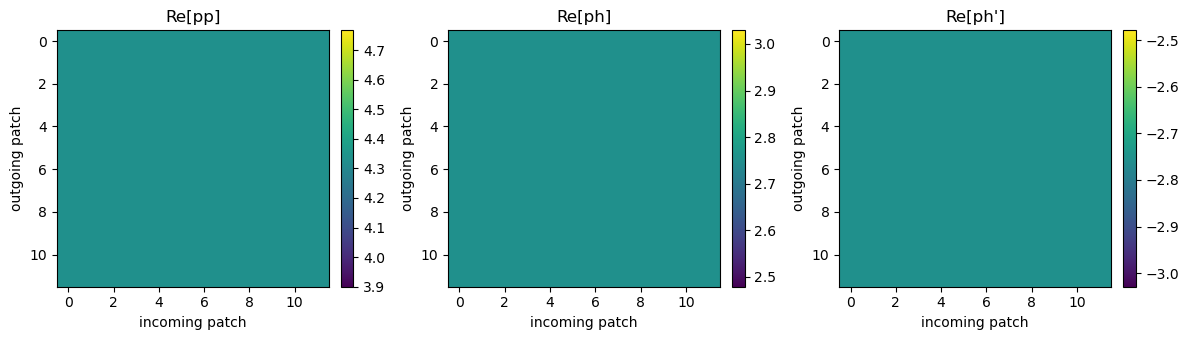

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, K, title in zip(
    axes,
    [Kpp, Kph, Kphc],
    ["pp", "ph", "ph'"],
):
    im = ax.imshow(np.real(K), aspect="auto")
    ax.set_title(f"Re[{title}]")
    ax.set_xlabel("incoming patch")
    ax.set_ylabel("outgoing patch")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 7. Optional: plug in your real kagome objects from Module 1

Replace the placeholders below with your real objects.

Typical target:

- `patchsets_real`: your actual up/down patch sets from Module 1
- `gamma_real`: your actual antisymmetrized patch-space vertex accessor or block dictionary
- `Q_list_real`: transfer vectors you care about, for example `Q=0` and the three symmetry-related \(M\)-vectors

Then repeat the same tests:

- zero / \(U^2\) scaling if possible
- SU(2) check
- channel norms and leading eigenvalues vs temperature
- compare symmetry-equivalent \(Q\)'s to detect artificial symmetry breaking


In [21]:
# Example scaffold only — edit this to match your own pipeline objects.

# patchsets_real = {"up": patchset_up, "dn": patchset_dn}
# gamma_real = gamma_accessor_or_tensor_dict
# Q_list_real = [Q0, QM1, QM2, QM3]

# cfg_real = fk.FlowConfig(temperature=0.1, nfreq=256)
# Kpp_real = fk.compute_pp_kernel(gamma_real, patchsets_real, Q0, incoming_spins=("up", "dn"), config=cfg_real)
# Kph_real = fk.compute_ph_kernel(gamma_real, patchsets_real, QM1, incoming_spins=("up", "up"), config=cfg_real)
# Kphc_real = fk.compute_phc_kernel(gamma_real, patchsets_real, QM1, incoming_spins=("up", "up"), config=cfg_real)

# print_summary(summarize_kernel("real pp", Kpp_real.matrix))
# print_summary(summarize_kernel("real ph", Kph_real.matrix))
# print_summary(summarize_kernel("real ph'", Kphc_real.matrix))


## 8. Failure diagnosis map

If a test fails, this is the shortest useful debug map.

### A. Zero interaction does not give zero
Most likely:
- wrong contraction algebra
- stale cache / wrong vertex accessor

### B. \(U^2\) scaling fails badly
Most likely:
- contraction uses wrong vertex twice
- hidden additive term in kernel assembly

### C. `Kph_uu != Kph_dd` in the synthetic SU(2) setup
Most likely:
- spin-block indexing error
- different patch sets accidentally used for up/down

### D. Large transpose error in a block that should be symmetric
Most likely:
- leg-order convention mismatch
- shifted patch partner map is inconsistent

### E. Temperature trends are erratic and unstable when `nfreq` changes
Most likely:
- Matsubara handling / insufficient frequency cutoff
- propagator derivative issue

### F. Real kagome run breaks symmetry between equivalent \(M\)-vectors
Most likely:
- patch mapping / BZ wrapping
- gauge-fixing inconsistency in patch construction
